<b>PARTIE A : <b> <a>  NETTOYAGE DES DONNEES  

Cette partie consiste à nettoyer et préparer le dataset. 

Un nettoyage des données assure la qualité des données et améliore la performance des modèles.

<b>A .1/ <b> <a>  Importation des librairies necessaires

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk              
import contractions
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer  # permet de calculer IF, IDF et IF*IDF et les mettre ds un vecteur
from wordcloud  import WordCloud                             # Permet d'afficher les mots les plus fréquents dans les commentaires des utilisateurs
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.stats import uniform, randint
from sklearn.model_selection import learning_curve
from ftfy import fix_text

<b> A . 2/ <b> <a>  Chargement du jeu de données

In [ ]:
# Le chemin de mon repertoire de travail

import os
os.chdir(r"C:\Users\hp\OneDrive\Bureau\Analyse_de_sentiment")

In [5]:
df=pd.read_csv("1_Data/1_1_Data_raw/YoutubeCommentsDataSet.csv")
df.head()

,Comment,Sentiment
0,lets not forget that apple pay in 2014 require...,neutral
1,here in nz 50 of retailers don’t even have con...,negative
2,i will forever acknowledge this channel with t...,positive
3,whenever i go to a place that doesn’t take app...,negative
4,apple pay is so convenient secure and easy to ...,positive


<b> A . 3 /<a>  Les informations sur le dataset

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18408 entries, 0 to 18407
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Comment    18364 non-null  object
 1   Sentiment  18408 non-null  object
dtypes: object(2)
memory usage: 287.8+ KB


<b> A . 4 /<a>  Distribution du sentiment

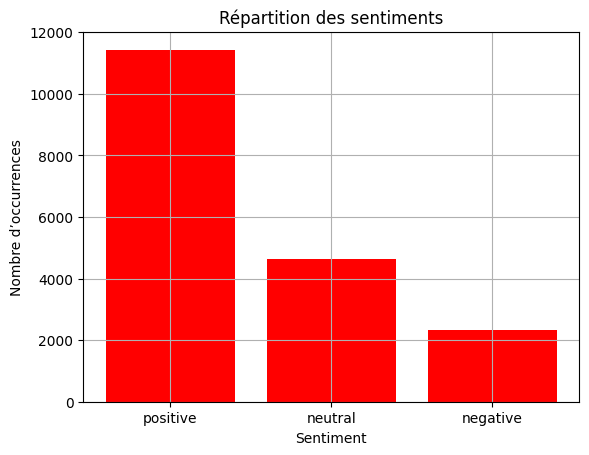

In [9]:
counts = df["Sentiment"].value_counts()
# Afficher un barplot avec les catégories bien centrées
plt.bar(counts.index, counts.values, color="red")
plt.xlabel("Sentiment")
plt.ylabel("Nombre d’occurrences")
plt.title("Répartition des sentiments")
plt.grid(True)
plt.show()

<b> A . 5 /<a> Vérification des valeurs manquantes

In [10]:
df.isnull().sum()

Comment      44
Sentiment     0
dtype: int64

D'aprés les informations ci-dessus, le jeu de données contient 44 observations qui n'ont pas été commentées.

<b> A . 6 /<a> Vérification des doublons

In [11]:
df.duplicated().sum()

531

L'ensemble des données contient 531 enregistrements identiques c'est-à-dire 531 utilisateurs qui ont  les memes point de vus (commentaires) et les memes sentiments.

<b> A . 7 /<a> Vérification du type des données

In [12]:
df.dtypes

Comment      object
Sentiment    object
dtype: object

Le jeu de données est constitué d'un seul types de données : object

<b> A . 8 /<a> Suppréssion des valeurs manquantes

In [13]:
df.dropna(inplace=True)

In [15]:
# VERIFICATION DES VALEURS MANQUANTES
df.isnull().sum()

Comment      0
Sentiment    0
dtype: int64

<b> A . 9 /<a> Suppréssion des doublons

In [14]:
df.drop_duplicates(inplace=True)

In [16]:
# VERIFICATION DES DOUBLONS
df.duplicated().sum()

0

<b> A . 10 / <a>Cleaning summary

Les étapes suivantes étaient réalisées dans la partie A:

- Les informations sur les variables

- vérification  des valeurs manquantes

- vérification des doublons

- vérification du type des données

- Suppréssion des valeurs manquantes

- Suppréssion des doublons

---------------------------------------------------------------------------------

<b>PARTIE B : <b> <a>  TRAITEMENT DU TEXTE 

<b> B . 1 /<a> Affichage des mots les plus fréquents

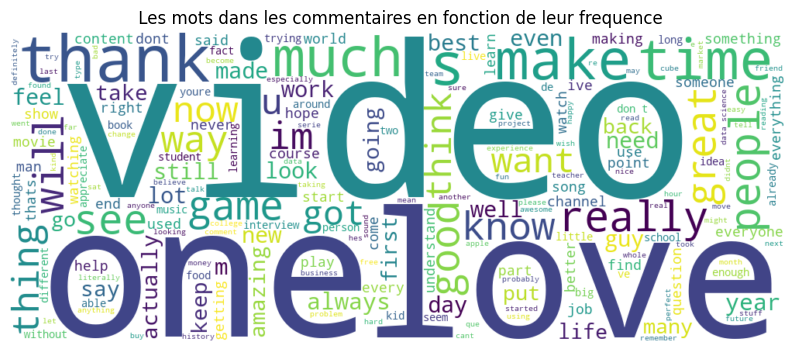

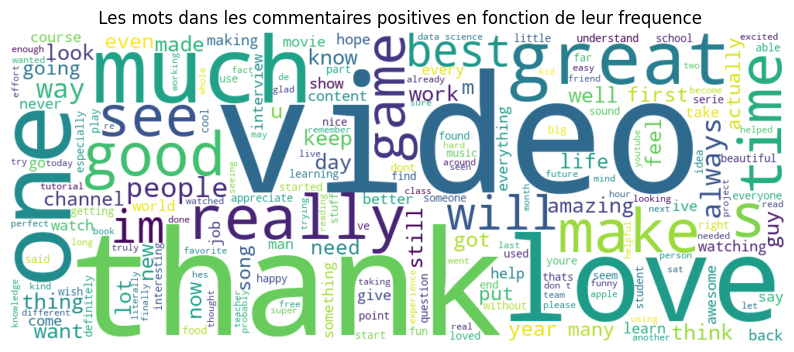

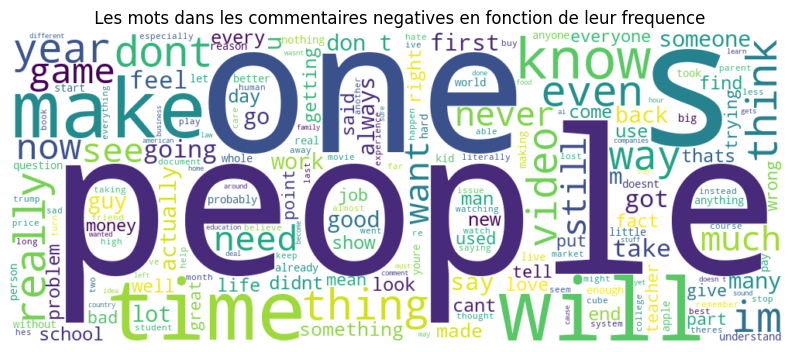

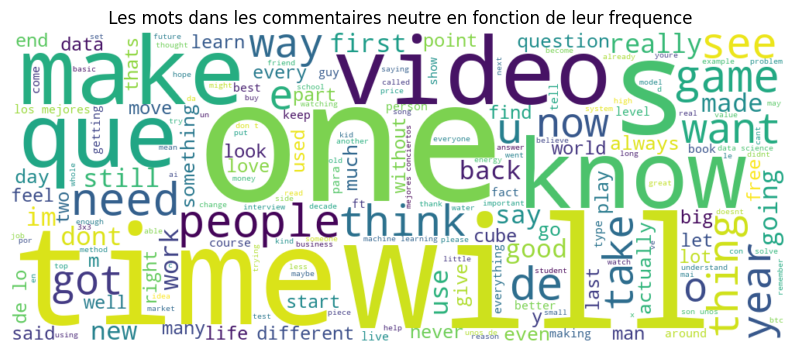

In [24]:
def affichage_des_mots(Comment,titre):
    text="".join(Comment)  # Cela concatène tous les éléments de la variable Comment en une seule chaîne de caractères, sans espace entre eux:EXE Comment = ["Bonjour", "tout", "le", "monde"] print(text) affiche :Bonjourtoutlemonde
    mots=WordCloud(width=1000,height=400,background_color="white").generate(text)
    plt.figure(figsize=(10,5))
    plt.imshow(mots,interpolation="bilinear") # pour afficher les images
    plt.title(titre,fontsize=12)
    plt.axis("off")     # pour enlever les valeurs sur laxe des abcisses et ordonnées 
    plt.show()

affichage_des_mots(df["Comment"]," Les mots dans les commentaires en fonction de leur frequence")
affichage_des_mots(df["Comment"][df["Sentiment"]=="positive"]," Les mots dans les commentaires positives en fonction de leur frequence")
affichage_des_mots(df["Comment"][df["Sentiment"]=="negative"]," Les mots dans les commentaires negatives en fonction de leur frequence")
affichage_des_mots(df["Comment"][df["Sentiment"]=="neutral"]," Les mots dans les commentaires neutre en fonction de leur frequence")

<b> B . 2 /<a>  Les différentes étapes à appliquer aux données textuelles

NLTK (Natural Language Toolkit) est une bibliothèque Python très utilisée en NLP pour les tâches de prétraitement textuel: Tokenisation, Stopwords, Stemming, Lemmatization, POS Tagging, Corpora intégrés et Analyse syntaxique.

- Tokenisation : Découper un texte en mots ou en phrases. EXE: "Je vais bien" → ["Je", "vais", "bien"]
- Stopwords : Liste de mots "vides" à filtrer. EXE: "et", "le", "de"...
- Stemming : Réduction d’un mot à sa racine. EXE: "marchant", "marche" → "march"
- Lemmatization : Réduction à la forme de base (plus propre que le stemming). EXE: "étaient" → "être"
- POS Tagging : Identifier les natures grammaticales (nom, verbe, etc.). EXE: "mange" → verbe
- Corpora intégrés :Textes d’exemple, dictionnaires, lexiques linguistiques. EXE: Shakespeare, Gutenberg, etc.
- Analyse syntaxique :Comprendre la structure grammaticale. EXE: Arbres syntaxiques

<b> B . 3 /<a>  Construction d'une fonction pipeline pour appliquer les étapes de netoyage du texte

In [38]:
# Télécharger les ressources nécessaires (à faire une seule fois)    
nltk.download('stopwords')   # Sert à utiliser les stop words (mots vides) comme “le”, “de”, “et”, “is”, “the”, etc.
nltk.download('punkt_tab')   # Sert à tokeniser du texte, c’est-à-dire découper un texte en mots ou en phrases.# Forcer le téléchargement de punkt
nltk.download('wordnet')

"""
    Nettoie un texte pour NLP :
    - Mise en minuscules
    - Suppression de ponctuation, HTML, chiffres
    - Tokenisation
    - Lemmatisation
    - Suppression des stopwords
"""



def nettoyer_texte(textes):  # cette fonction n'est rien d'autre qu'un pipeline car une sequence d'étapes à escuter pour sortir un resultat final 
    # 0.fix_text:conçue pour corriger les textes mal encodés.EXE:donâ€™t → don’t
    textes = fix_text(textes)
    # 1. Expand contractions # contractions transforme les elements cad (ex: can't → can not , I'll → I will, won't → will not) :Ce qui permet :
    # de normaliser tous les textes d’avoir une représentation cohérente des mots et donc de meilleurs résultats pour la classification de sentiments ou autre.
    textes = contractions.fix(textes) 
    # 2. Mise en minuscules
    textes = textes.lower()
    # 3. Supprimer certaines ponctuations et caractères spéciaux
    textes = re.sub(r"[,\!\?\%\(\)/\"'@]", "", textes)   # !"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~
    # 4. Supprimer les entités HTML comme &nbsp;
    textes = re.sub(r"&\S*\s", "", textes)
    # 5. Supprimer les tirets
    textes = re.sub(r"-", "", textes)
    # 6. Supprimer les chiffres
    textes = re.sub(r"\d+", "", textes)
    # 7. Tokenisation
    mots = word_tokenize(textes, language='english')
    # 8. Stopwords : garde les mots importants  apres tokenisation et supprime les mots unitiles comme: "et", "le", "de"...
    stopwords_en = set(stopwords.words('english'))
    # Liste des mots négatifs à conserver pendant le stopwords(car tres importants en analyse de sentiments.(si cetait detection spam cest pas la peine)
    negations = [
        "not", "no", "nor", "never", "neither", "don't", "can't", "didn't", "wasn't", "isn't",
        "won't", "wouldn't", "shouldn't", "couldn't", "doesn't", "haven't", "hasn't", "hadn't", "mustn't", "needn't",
        "mightn't", "shan't", "may not", "might not", "have not","has not", "had not", "could not", "would not", "should not",
        "have", "has","had","might","was","were","can","may","is","do","did","does","must", "should"]


    for neg in negations:
        stopwords_en.discard(neg)

    # 9. Filtrage des mots : suppression des stopwords sauf négations, et des tokens non alphabétiques
    mots_utiles = [mot for mot in mots if mot.isalpha() and mot not in stopwords_en] # .isalpha() :Pour texte plus propre, utile pour la plupart des modèles NLP
    # 10. Lemmatisation :mieux repérer les mots porteurs d’émotion, quel que soit le temps ou la conjugaison
    # améliorer la précision des modèles de sentiment (classifieurs, lexiques, embeddings...)
    lemmatizer = WordNetLemmatizer()
    lemmes = [lemmatizer.lemmatize(mot, pos='v') for mot in mots_utiles]
    # 11. Reconstituer le texte nettoyé
    textes = " ".join(lemmes)

    return textes   #cad Retourner le texte apres avoir appliques toutes les etapes ci dessus

[nltk_data] Downloading package stopwords to C:\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to C:\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


<b> B . 3 . 1 / <a>Vérification de la fonction nettoyer_texte definit ci-dessus:

In [39]:
texte_1="here in nz 50 of retailers donâ€™t even have contactless credit card machines like paywave which support apple pay they donâ€™t like the high fees that come with these"
print("le resultat de la fonction appliqué à cet exemple texte_1 donne :")
nettoyer_texte(texte_1)

le resultat de la fonction appliqué à cet exemple texte_1 donne :


'nz retailers do not even have contactless credit card machine like paywave support apple pay do not like high fee come'

<b> B . 3 . 2 /<a>  Création d'une nouvelle colonne nommée "Comment_nettoye" et application de la fonction nettoyer_text dans la colonne "Comment"

In [40]:
df["Comment_nettoye"]=df["Comment"].apply(nettoyer_texte)
df.head()

,Comment,Sentiment,Comment_nettoye
0,lets not forget that apple pay in 2014 require...,neutral,let us not forget apple pay require brand new ...
1,here in nz 50 of retailers don’t even have con...,negative,nz retailers do not even have contactless cred...
2,i will forever acknowledge this channel with t...,positive,forever acknowledge channel help lessons ideas...
3,whenever i go to a place that doesn’t take app...,negative,whenever go place do not take apple pay do not...
4,apple pay is so convenient secure and easy to ...,positive,apple pay be convenient secure easy use use ko...


<b> B . 4 /<a>  Transformation du texte  prétraité en chaine numérique

Pour cela, on utilse TfidfVectorizer ou bien COUNTVectorizer

- TF (frequence des termes) :mesure le nombre de fois qu'un terme apparait dans un document
- IDF (frequence inverse dans les documents):evalue l'importance d'un terme dans la collection globale de documents
- IDF=log(nbr documents/nbr dapparition total dun terme dans lensemble des documents)
- En utilisant IF-IDF, on peut attribuer une valeur numérique (=IF*IDF) a chaque terme , reflétant a la fois sa frequence dans le document et son importance relative dans la collection de documents
- Le poids
$$ W_{x,y}=tf_{x}*log(N/df_{x}) $$

<b> B . 4 . 1 /<a> Un exemple pour voir comment ça marche la vectorisation :

In [42]:
#EXEMPLE: rien a avoir avec la modelisation juste pour voir comment fonctionne la vectorisation
vectorizer_ex=TfidfVectorizer()
donnee=vectorizer_ex.fit_transform(df["Comment_nettoye"])
donnee=donnee.toarray()
print("Dimension de la matrice de caracteristique",donnee.shape)
donnee

Dimension de la matrice de caracteristique (17874, 30787)


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

-----------------------------------------

<b>PARTIE C :  <a>  APPRENTISSAGE ET EVALUATION DES MODELES 

<b> C . 1 /<a> Introduction

L'objectif de cette partie est d'entrainer plusieurs modèles pour la prédiction et de comparer leur performance.

Differents alguorithmes seront evalués pour identifier le modèle plus convenable pour le deployment.

<b> C . 2 /<a> Réequilibrage des données

In [44]:
sentiment_positive= df[df["Sentiment"]=="positive"].sample(n=2500,random_state=33) # on a choisit aléatoirement 2500 commentaires positive 
sentiment_negative= df[df["Sentiment"]=="negative"].sample(n=2100,random_state=33) # on a choisit aléatoirement 2337 commentaires negative
sentiment_neutral= df[df["Sentiment"]=="neutral"].sample(n=2100,random_state=33)   # on a choisit aléatoirement 2337 commentaires neutre
df_equilibre=pd.concat([sentiment_positive,sentiment_negative,sentiment_neutral])    # notre nouveau dataset équilibré 
df_equilibre["Sentiment"].value_counts(normalize=True)*100

Sentiment
positive    37.313433
negative    31.343284
neutral     31.343284
Name: proportion, dtype: float64

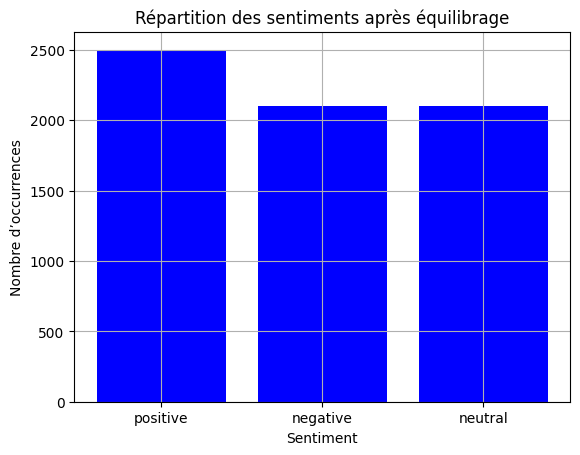

In [46]:
counts = df_equilibre["Sentiment"].value_counts()
# Afficher un barplot avec les catégories bien centrées
plt.bar(counts.index, counts.values, color="blue")
plt.xlabel("Sentiment")
plt.ylabel("Nombre d’occurrences")
plt.title("Répartition des sentiments après équilibrage")
plt.grid(True)
plt.show()

<b> C . 3 /<a> Division du dataset en train et test 

In [48]:
# ok
from sklearn.model_selection import train_test_split

X=df_equilibre["Comment_nettoye"]
Y=df_equilibre["Sentiment"]

X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,stratify=Y,random_state=30) #stratify permet de préserver 
                                                             # la proportion des classes entre l'entraînement et le test.

<b> C . 4 /<a> Création d'une fonction TextCleaner 

In [49]:
""" 
Création d'une fonction TextCleaner
La fonction TextCleaner est constituée de 3 étapes :

1/ Vérification si X est un tableau NumPy :
Si l'entrée X est un tableau NumPy (par exemple un tableau de chaînes de caractères), on le transforme en tableau 1D (vectorisé).
Pourquoi ? Parce que scikit-learn aime les données plates (pas des tableaux imbriqués ou 2D inutiles pour du texte).
2/ Conversion en pandas Series :
Si X n'est pas déjà une pandas.Series, on le convertit.
Pourquoi ? Parce que la méthode .apply() est très pratique sur une Series pour appliquer une fonction à chaque élément.
3/ Nettoyage des valeurs manquantes :
Les valeurs NaN ou None (manquantes) sont remplacées par une chaîne vide "".
Puis la fonction nettoyer_texte est appliquée sur chaque élément de la Series.

"""

' \nCréation d\'une fonction TextCleaner\nLa fonction TextCleaner est constituée de 3 étapes :\n\n1/ Vérification si X est un tableau NumPy :\nSi l\'entrée X est un tableau NumPy (par exemple un tableau de chaînes de caractères), on le transforme en tableau 1D (vectorisé).\nPourquoi ? Parce que scikit-learn aime les données plates (pas des tableaux imbriqués ou 2D inutiles pour du texte).\n2/ Conversion en pandas Series :\nSi X n\'est pas déjà une pandas.Series, on le convertit.\nPourquoi ? Parce que la méthode .apply() est très pratique sur une Series pour appliquer une fonction à chaque élément.\n3/ Nettoyage des valeurs manquantes :\nLes valeurs NaN ou None (manquantes) sont remplacées par une chaîne vide "".\nPuis la fonction nettoyer_texte est appliquée sur chaque élément de la Series.\n\n'

In [50]:

class TextCleaner(BaseEstimator, TransformerMixin):
    """
    Transformer sklearn pour nettoyer les textes via la fonction 'nettoyer_texte'.
    """
    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        # Si c'est un tableau numpy, le convertir en 1D
        if isinstance(X, np.ndarray):
            X = X.ravel()  # rend le tableau plat 1D
        # Si c'est une liste ou autre, le transformer en Series
        X = pd.Series(X) if not isinstance(X, pd.Series) else X
        # Nettoyage des NaN ou None en les remplaçant par une chaîne vide "",Puis la fonction nettoyer_texte est appliquée sur chaque élément de la Series.
        return X.fillna("").apply(nettoyer_texte)

<b> C . 5 /<a> Apprentissage du modèle MultinomialNB

In [52]:
# PIPELINE POUR AUTOMATISER LES DIFFERENTES ETAPES: nettoyage-vectorisation-modélisation 
pipe_NB=make_pipeline( TextCleaner(),
                   TfidfVectorizer(),
                   MultinomialNB() )

              precision    recall  f1-score   support

    negative       0.68      0.69      0.69       420
     neutral       0.77      0.25      0.38       420
    positive       0.59      0.91      0.72       500

    accuracy                           0.64      1340
   macro avg       0.68      0.62      0.59      1340
weighted avg       0.67      0.64      0.60      1340



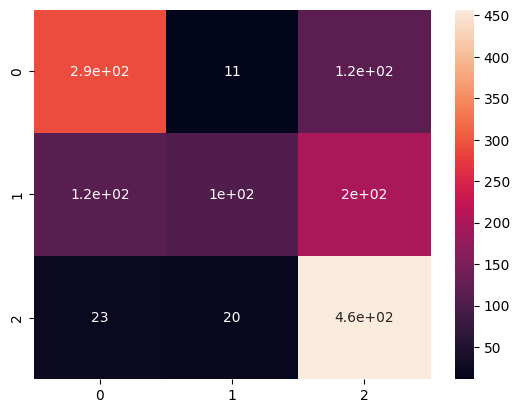

In [53]:
modeleNB=pipe_NB.fit(X_train,Y_train)
prediction=modeleNB.predict(X_test)
print(classification_report(Y_test,prediction))

sns.heatmap(confusion_matrix(Y_test,prediction),annot=True)  
plt.show()

<b> C . 6 /<a> Apprentissage du modèle LogisticRegression

In [54]:
# PIPELINE POUR AUTOMATISER LES DIFFERENTES ETAPES: nettoyage-vectorisation-modélisation 
pipe_LR=make_pipeline( TextCleaner(),
                   TfidfVectorizer(),
                   LogisticRegression() )

              precision    recall  f1-score   support

    negative       0.66      0.68      0.67       420
     neutral       0.59      0.61      0.60       420
    positive       0.79      0.76      0.78       500

    accuracy                           0.69      1340
   macro avg       0.68      0.68      0.68      1340
weighted avg       0.69      0.69      0.69      1340



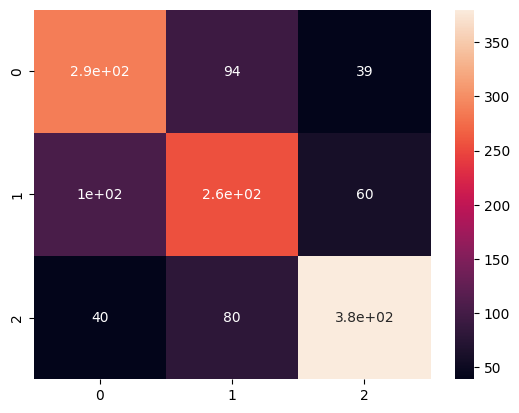

In [55]:
modeleLR=pipe_LR.fit(X_train,Y_train)
prediction=modeleLR.predict(X_test)
print(classification_report(Y_test,prediction))

sns.heatmap(confusion_matrix(Y_test,prediction),annot=True)  
plt.show()

<b> C . 7 /<a> Apprentissage du modèle SVC

In [56]:
# PIPELINE POUR AUTOMATISER LES DIFFERENTES ETAPES: nettoyage-vectorisation-modélisation 
pipe_SVC=make_pipeline( TextCleaner(),
                   TfidfVectorizer(),
                   SVC() )

              precision    recall  f1-score   support

    negative       0.65      0.70      0.68       420
     neutral       0.59      0.62      0.60       420
    positive       0.82      0.74      0.77       500

    accuracy                           0.69      1340
   macro avg       0.69      0.69      0.69      1340
weighted avg       0.69      0.69      0.69      1340



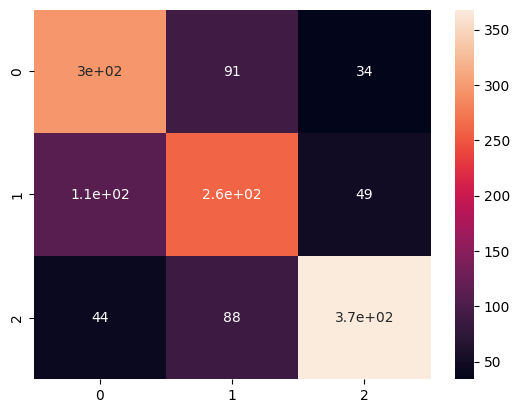

In [57]:
modeleSVC=pipe_SVC.fit(X_train,Y_train)
prediction=modeleSVC.predict(X_test)
print(classification_report(Y_test,prediction))

sns.heatmap(confusion_matrix(Y_test,prediction),annot=True)  
plt.show()

<b> C . 8 /<a> Apprentissage du modèle RandomForestClassifier

In [58]:
# PIPELINE POUR AUTOMATISER LES DIFFERENTES ETAPES: nettoyage-vectorisation-modélisation 
pipe_RF=make_pipeline( TextCleaner(),
                   TfidfVectorizer(),
                   RandomForestClassifier() )

              precision    recall  f1-score   support

    negative       0.62      0.70      0.66       420
     neutral       0.64      0.55      0.60       420
    positive       0.77      0.76      0.76       500

    accuracy                           0.68      1340
   macro avg       0.67      0.67      0.67      1340
weighted avg       0.68      0.68      0.68      1340



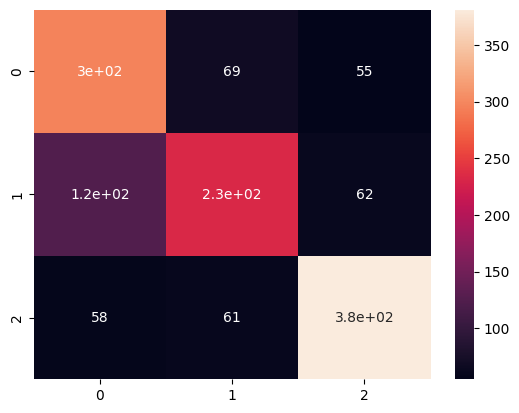

In [59]:
modeleRF=pipe_RF.fit(X_train,Y_train)
prediction=modeleRF.predict(X_test)
print(classification_report(Y_test,prediction))

sns.heatmap(confusion_matrix(Y_test,prediction),annot=True)  
plt.show()

NB: en entreprise, on choisit le modele en fonction des performances et des contraintes metier, pas parcequ'il est populaire

<b> C . 9 /<a> Sélection du meilleur moDèle

Dans notre contexte, prédire qu’un commentaire est positif alors qu'il est en réalité neutre ou négatif est plus problématique que de prédire qu’un commentaire est neutre ou négatif alors qu'il est en réalité positif. Nous allons donc chercher à minimiser les faux positifs, c’est-à-dire à maximiser la précision (scoring="precision_macro":recommandé pour un problème de sentiment à 3 classes (positif, négatif, neutre)) plutôt que le rappel. Au vu des différentes précisions des modèles présentés ci-dessus, on constate que le modèle SVC obtient les meilleures valeurs de précision et de F1-score.

<b> C . 10 /<a> Optimisation du modèle sélectioné

In [60]:
param_distributions = {
    'svc__C': uniform(0.1, 100),                         # Valeurs continues entre 0.1 et 100
    'svc__kernel': ['linear', 'rbf', 'poly', 'sigmoid'],  # Choix parmi 4 noyaux
    'svc__gamma': ['scale', 'auto', 0.01, 0.1, 1],        # Valeurs possibles de gamma
    'svc__degree': randint(2, 5),                         # Degré du polynôme entre 2 et 4
    'svc__class_weight': [None, 'balanced']    }          # Gestion du déséquilibre

random_search = RandomizedSearchCV(
    pipe_SVC,
    param_distributions=param_distributions,
    n_iter=20,                     # Nombre d'échantillons aléatoires à tester (modifiable)
    cv=3,
    scoring='precision_macro',     # Calcule la précision pour chaque classe séparément.Puis fait la moyenne simple des précisions des classes (sans tenir compte du déséquilibre des classes).Bon choix pour les problèmes multiclasses équilibrés ou quand toutes les classes ont la même importance.
    n_jobs=1,                      # Pour éviter l'erreur BrokenProcessPool
    verbose=2,
    random_state=42   )

# Entraînement
random_search.fit(X_train, Y_train)

# Meilleurs hyperparamètres trouvés
print("Meilleurs paramètres trouvés : ", random_search.best_params_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END svc__C=37.55401188473625, svc__class_weight=None, svc__degree=4, svc__gamma=0.01, svc__kernel=sigmoid; total time=  37.9s
[CV] END svc__C=37.55401188473625, svc__class_weight=None, svc__degree=4, svc__gamma=0.01, svc__kernel=sigmoid; total time=  23.3s
[CV] END svc__C=37.55401188473625, svc__class_weight=None, svc__degree=4, svc__gamma=0.01, svc__kernel=sigmoid; total time=  16.5s


c:\Users\hp\OneDrive\Documents\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[CV] END svc__C=59.96584841970366, svc__class_weight=None, svc__degree=3, svc__gamma=0.01, svc__kernel=poly; total time=  21.4s


c:\Users\hp\OneDrive\Documents\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[CV] END svc__C=59.96584841970366, svc__class_weight=None, svc__degree=3, svc__gamma=0.01, svc__kernel=poly; total time=  20.7s


...

[CV] END svc__C=96.2172024349349, svc__class_weight=None, svc__degree=2, svc__gamma=auto, svc__kernel=poly; total time=  38.9s


c:\Users\hp\OneDrive\Documents\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[CV] END svc__C=96.2172024349349, svc__class_weight=None, svc__degree=2, svc__gamma=auto, svc__kernel=poly; total time=  34.9s


c:\Users\hp\OneDrive\Documents\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[CV] END svc__C=96.2172024349349, svc__class_weight=None, svc__degree=2, svc__gamma=auto, svc__kernel=poly; total time=  38.4s
[CV] END svc__C=82.97375091519292, svc__class_weight=balanced, svc__degree=2, svc__gamma=0.1, svc__kernel=sigmoid; total time=  40.4s
[CV] END svc__C=82.97375091519292, svc__class_weight=balanced, svc__degree=2, svc__gamma=0.1, svc__kernel=sigmoid; total time=  32.3s
[CV] END svc__C=82.97375091519292, svc__class_weight=balanced, svc__degree=2, svc__gamma=0.1, svc__kernel=sigmoid; total time=  34.6s
[CV] END svc__C=54.36960831582485, svc__class_weight=None, svc__degree=2, svc__gamma=1, svc__kernel=linear; total time=  35.2s
[CV] END svc__C=54.36960831582485, svc__class_weight=None, svc__degree=2, svc__gamma=1, svc__kernel=linear; total time=  32.5s
[CV] END svc__C=54.36960831582485, svc__class_weight=None, svc__degree=2, svc__gamma=1, svc__kernel=linear; total time=  31.1s
[CV] END svc__C=1.6636406741193932, svc__class_weight=None, svc__degree=2, svc__gamma=0.1,

<b> C . 11 /<a> Evaluation du modèle optimisé


Rapport de classification :
               precision    recall  f1-score   support

    negative       0.65      0.70      0.68       420
     neutral       0.58      0.65      0.61       420
    positive       0.84      0.69      0.76       500

    accuracy                           0.68      1340
   macro avg       0.69      0.68      0.68      1340
weighted avg       0.70      0.68      0.69      1340



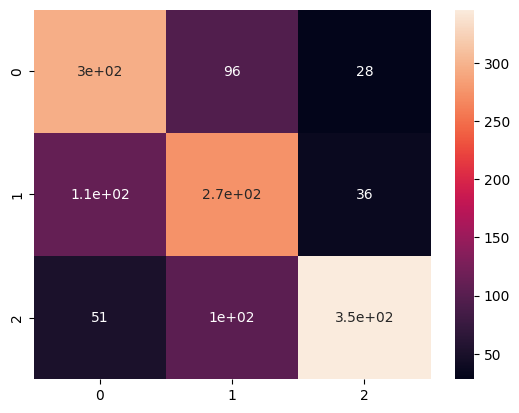

In [61]:
# Évaluation sur le jeu de test
best_model_SVC = random_search.best_estimator_
y_pred = best_model_SVC.predict(X_test)
print("\nRapport de classification :\n", classification_report(Y_test, y_pred))

sns.heatmap(confusion_matrix(Y_test,y_pred),annot=True)  
plt.show()

<b>PARTIE D :  <a>  SAUVEGARDE DES MODELES

In [62]:
import pickle

pickle.dump(modeleNB,open ("MultinomialNB.sav", "wb"))

In [63]:
pickle.dump(modeleLR,open ("LogisticRegression(.sav", "wb"))

In [64]:
pickle.dump(modeleSVC,open ("Modele_SVC.sav", "wb"))

In [65]:
pickle.dump(modeleRF,open ("RandomForestClassifier.sav", "wb"))

In [66]:
pickle.dump(best_model_SVC,open ("Model_SVC_optimisé.sav", "wb"))